# Improved Feature Engineering
Улучшенная версия baseline с LF/HF HRV, оконными признаками и починенной глюкозой.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

DATA    = Path('../data/raw/dataset_wearables')
RESULTS = Path('../results/figures')
RESULTS.mkdir(parents=True, exist_ok=True)

PHASE_ORDER = ['Menstrual', 'Follicular', 'Fertility', 'Luteal']
JOIN_KEYS   = ['id', 'study_interval', 'day_in_study']

print('OK')

OK


In [3]:
# Загрузка данных
hormones = pd.read_csv(DATA / 'hormones_and_selfreport.csv')
temp     = pd.read_csv(DATA / 'computed_temperature.csv')
hrv_raw  = pd.read_csv(DATA / 'heart_rate_variability_details.csv')
wrist_t  = pd.read_csv(DATA / 'wrist_temperature.csv')
resp     = pd.read_csv(DATA / 'respiratory_rate_summary.csv')
gluc_raw = pd.read_csv(DATA / 'glucose.csv')

print(f'Hormones  : {hormones.shape}  — {hormones["id"].nunique()} subjects')
print(f'Temp      : {temp.shape}  — {temp["id"].nunique()} subjects')
print(f'HRV raw   : {hrv_raw.shape} — {hrv_raw["id"].nunique()} subjects')
print(f'Wrist T   : {wrist_t.shape} — {wrist_t["id"].nunique()} subjects')
print(f'Resp rate : {resp.shape}  — {resp["id"].nunique()} subjects')
print(f'Glucose   : {gluc_raw.shape} — {gluc_raw["id"].nunique()} subjects')


Hormones  : (5659, 22)  — 42 subjects
Temp      : (5575, 14)  — 42 subjects
HRV raw   : (436262, 9) — 40 subjects
Wrist T   : (6856019, 6) — 42 subjects
Resp rate : (6301, 17)  — 40 subjects
Glucose   : (837130, 6) — 42 subjects


In [4]:
# Фикс единиц глюкозы: значения > 20 — это mg/dL, конвертируем в mmol/L
print('before fix:')
print(gluc_raw['glucose_value'].describe().round(3))

gluc_raw['glucose_value'] = gluc_raw['glucose_value'].apply(
    lambda x: x / 18.0 if x > 20 else x
)

print('\nAfter fix:')
print(gluc_raw['glucose_value'].describe().round(3))
print(f'\nValues > 20 remaining: {(gluc_raw["glucose_value"] > 20).sum()}')


before fix:
count    835897.000
mean         10.715
std          22.594
min           2.200
25%           5.400
50%           6.100
75%           6.900
max         253.000
Name: glucose_value, dtype: float64

After fix:
count    835897.000
mean          6.160
std           1.194
min           2.200
25%           5.400
50%           6.000
75%           6.800
max          15.500
Name: glucose_value, dtype: float64

Values > 20 remaining: 0


In [5]:
# Шаг 1 — агрегируем каждый столбец отдельно
hrv_daily = (
    hrv_raw
    .groupby(JOIN_KEYS)
    .agg(
        hrv_mean   = ('rmssd', 'mean'),
        hrv_std    = ('rmssd', 'std'),
        hrv_median = ('rmssd', 'median'),
        lf_mean    = ('low_frequency', 'mean'),
        hf_mean    = ('high_frequency', 'mean'),
    )
    .reset_index()
)

# Шаг 2 — считаем ratio отдельно
hrv_daily['lf_hf_ratio'] = hrv_daily['lf_mean'] / hrv_daily['hf_mean'].replace(0, np.nan)

print(f'HRV daily: {hrv_daily.shape}')
print(hrv_daily[['hrv_mean', 'lf_mean', 'hf_mean', 'lf_hf_ratio']].describe().round(2))


HRV daily: (4839, 9)
       hrv_mean  lf_mean  hf_mean  lf_hf_ratio
count   4839.00  4839.00  4839.00      4839.00
mean      55.06  1379.82   954.77         1.98
std       28.58   945.75   918.22         1.11
min        0.00    72.55    28.26         0.18
25%       33.93   640.64   337.28         1.24
50%       48.79  1149.08   627.16         1.71
75%       70.31  1875.21  1277.64         2.38
max      194.17  9253.91  8405.93        11.79


In [6]:
# Сортируем по субъекту и дню
wrist_t = wrist_t.sort_values(JOIN_KEYS + ['timestamp'])

# Slope: насколько температура росла/падала за ночь
def calc_slope(x):
    if len(x) < 2:
        return np.nan
    return np.polyfit(range(len(x)), x, 1)[0]  # коэффициент наклона

wrist_daily = (
    wrist_t
    .groupby(JOIN_KEYS)['temperature_diff_from_baseline']
    .agg(
        wt_diff_mean  = 'mean',
        wt_diff_std   = 'std',
        wt_diff_max   = 'max',
        wt_diff_min   = 'min',
        wt_slope      = calc_slope
    )
    .reset_index()
)

print(f'Wrist temp daily: {wrist_daily.shape}')
print(wrist_daily[['wt_diff_mean', 'wt_diff_std', 'wt_slope']].describe().round(4))


Wrist temp daily: (5138, 8)
       wt_diff_mean  wt_diff_std   wt_slope
count     5138.0000    5138.0000  5138.0000
mean        -1.7229       1.9638    -0.0022
std          0.9400       0.5799     0.0022
min         -8.1319       0.0035    -0.0296
25%         -2.2906       1.5409    -0.0032
50%         -1.6564       1.9083    -0.0020
75%         -1.0944       2.3384    -0.0011
max          2.2155       4.5637     0.0400


In [7]:
resp_daily = (
    resp
    .groupby(JOIN_KEYS)
    .agg(
        rr_full     = ('full_sleep_breathing_rate', 'mean'),
        rr_deep     = ('deep_sleep_breathing_rate', 'mean'),
        rr_rem      = ('rem_sleep_breathing_rate', 'mean'),
        rr_std      = ('full_sleep_standard_deviation', 'mean'),
    )
    .reset_index()
)

print(f'Resp rate daily: {resp_daily.shape}')
print(resp_daily[['rr_full', 'rr_deep', 'rr_rem']].describe().round(2))


Resp rate daily: (4739, 7)
       rr_full  rr_deep   rr_rem
count  4739.00  4739.00  4739.00
mean     15.49    15.17    11.69
std       2.97     3.72     6.35
min       0.00    -1.00    -1.00
25%      14.40    14.40    11.20
50%      15.60    15.50    14.00
75%      16.80    16.80    15.40
max      29.80    29.80    29.80


In [8]:
gluc_daily = (
    gluc_raw
    .groupby(JOIN_KEYS)['glucose_value']
    .agg(
        glucose_mean  = 'mean',
        glucose_std   = 'std',
        glucose_min   = 'min',
        glucose_max   = 'max',
        glucose_range = lambda x: x.max() - x.min()
    )
    .reset_index()
)

print(f'Glucose daily: {gluc_daily.shape}')
print(gluc_daily[['glucose_mean', 'glucose_std', 'glucose_range']].describe().round(3))


Glucose daily: (3109, 8)
       glucose_mean  glucose_std  glucose_range
count      3108.000     3107.000       3108.000
mean          6.156        0.912          4.743
std           0.751        0.285          1.400
min           2.931        0.000          0.000
25%           5.664        0.721          3.800
50%           6.133        0.874          4.600
75%           6.666        1.051          5.600
max           9.900        3.288         12.700


In [9]:
# Базовый таргет
target = hormones[JOIN_KEYS + ['phase']].copy()
target = target[target['phase'].isin(PHASE_ORDER)]

# Мерж
df = (
    target
    .merge(wrist_daily, on=JOIN_KEYS, how='inner')
    .merge(hrv_daily,   on=JOIN_KEYS, how='inner')
    .merge(resp_daily,  on=JOIN_KEYS, how='left')
    .merge(gluc_daily,  on=JOIN_KEYS, how='left')
)

# Убираем заглушки -1 из respiratory rate
for col in ['rr_full', 'rr_deep', 'rr_rem', 'rr_std']:
    if col in df.columns:
        df[col] = df[col].replace(-1, np.nan)

df = df.reset_index(drop=True)

print(f'Итого строк: {len(df)}')
print(f'Субъектов  : {df["id"].nunique()}')
print()
print('Phase distribution:')
print(df['phase'].value_counts().reindex(PHASE_ORDER))
print()
print('Missing values:')
feature_cols = ['wt_diff_mean','wt_diff_std','wt_slope',
                'hrv_mean','lf_mean','hf_mean','lf_hf_ratio',
                'rr_full','rr_deep','rr_rem',
                'glucose_mean','glucose_std']
print(df[feature_cols].isna().sum())


Итого строк: 4697
Субъектов  : 40

Phase distribution:
phase
Menstrual      884
Follicular    1161
Fertility     1065
Luteal        1587
Name: count, dtype: int64

Missing values:
wt_diff_mean       0
wt_diff_std        0
wt_slope           0
hrv_mean           0
lf_mean            0
hf_mean            0
lf_hf_ratio        0
rr_full           71
rr_deep          215
rr_rem           853
glucose_mean    2338
glucose_std     2338
dtype: int64


In [10]:
# Заполняем медианой по каждому субъекту, затем глобальной медианой
fill_cols = ['rr_full', 'rr_deep', 'rr_rem', 'rr_std',
             'glucose_mean', 'glucose_std', 'glucose_range']

for col in fill_cols:
    if col in df.columns:
        # Сначала медиана субъекта
        df[col] = df.groupby('id')[col].transform(
            lambda x: x.fillna(x.median())
        )
        # Затем глобальная медиана для субъектов без данных вообще
        df[col] = df[col].fillna(df[col].median())

print('Missing после заполнения:')
print(df[fill_cols].isna().sum())


Missing после заполнения:
rr_full          0
rr_deep          0
rr_rem           0
rr_std           0
glucose_mean     0
glucose_std      0
glucose_range    0
dtype: int64


In [11]:
FEATURES = [
    # Wrist temperature
    'wt_diff_mean', 'wt_diff_std', 'wt_slope',
    # HRV
    'hrv_mean', 'hrv_std', 'hrv_median',
    'lf_mean', 'hf_mean', 'lf_hf_ratio',
    # Respiratory rate
    'rr_full', 'rr_deep', 'rr_rem', 'rr_std',
    # Glucose
    'glucose_mean', 'glucose_std', 'glucose_range',
]

df_ml = df[['id', 'phase'] + FEATURES].dropna().reset_index(drop=True)

le = LabelEncoder()
le.fit(PHASE_ORDER)
df_ml['label'] = le.transform(df_ml['phase'])

X      = df_ml[FEATURES].values
y      = df_ml['label'].values
groups = df_ml['id'].values

print(f'Samples  : {X.shape[0]}  (было 2359 в 1 версии baseline)')
print(f'Features : {X.shape[1]}  (было 8 в 1 версии baseline)')
print(f'Subjects : {len(np.unique(groups))}')
print()
print('Class balance:')
for i, name in enumerate(le.classes_):
    print(f'  {name:12s}: {(y == i).sum()}')


Samples  : 4696  (было 2359 в 1 версии baseline)
Features : 16  (было 8 в 1 версии baseline)
Subjects : 40

Class balance:
  Fertility   : 1065
  Follicular  : 1161
  Luteal      : 1587
  Menstrual   : 883


In [12]:
logo = LeaveOneGroupOut()
clf  = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

all_true, all_pred, all_proba = [], [], []
n_splits = logo.get_n_splits(X, y, groups)

print(f'Running LOSO CV — {n_splits} folds...')
for fold, (train_idx, test_idx) in enumerate(logo.split(X, y, groups)):
    clf.fit(X[train_idx], y[train_idx])
    pred  = clf.predict(X[test_idx])
    proba = clf.predict_proba(X[test_idx])
    all_true.extend(y[test_idx])
    all_pred.extend(pred)
    all_proba.extend(proba)
    if (fold + 1) % 10 == 0:
        print(f'  Fold {fold+1}/{n_splits} done')

all_true  = np.array(all_true)
all_pred  = np.array(all_pred)
all_proba = np.array(all_proba)
print('Done.')


Running LOSO CV — 40 folds...
  Fold 10/40 done
  Fold 20/40 done
  Fold 30/40 done
  Fold 40/40 done
Done.


In [13]:
acc = accuracy_score(all_true, all_pred)
auc = roc_auc_score(all_true, all_proba, multi_class='ovr', average='macro')

print('=' * 52)
print(f'  Accuracy : {acc*100:.1f}%   (было 33.3% в baseline)')
print(f'  AUC-ROC  : {auc:.3f}    (было 0.547 в baseline)')
print('=' * 52)
print()
print(classification_report(all_true, all_pred, target_names=le.classes_))


  Accuracy : 31.5%   (было 33.3% в baseline)
  AUC-ROC  : 0.542    (было 0.547 в baseline)

              precision    recall  f1-score   support

   Fertility       0.18      0.09      0.12      1065
  Follicular       0.30      0.36      0.33      1161
      Luteal       0.37      0.55      0.44      1587
   Menstrual       0.24      0.11      0.15       883

    accuracy                           0.32      4696
   macro avg       0.27      0.28      0.26      4696
weighted avg       0.28      0.32      0.28      4696



In [14]:
FEATURES_NO_GLUC = [
    'wt_diff_mean', 'wt_diff_std', 'wt_slope',
    'hrv_mean', 'hrv_std', 'hrv_median',
    'lf_mean', 'hf_mean', 'lf_hf_ratio',
    'rr_full', 'rr_deep', 'rr_rem', 'rr_std',
]

X2 = df_ml[FEATURES_NO_GLUC].values

all_true2, all_pred2, all_proba2 = [], [], []
for fold, (train_idx, test_idx) in enumerate(logo.split(X2, y, groups)):
    clf.fit(X2[train_idx], y[train_idx])
    pred  = clf.predict(X2[test_idx])
    proba = clf.predict_proba(X2[test_idx])
    all_true2.extend(y[test_idx])
    all_pred2.extend(pred)
    all_proba2.extend(proba)

all_true2  = np.array(all_true2)
all_pred2  = np.array(all_pred2)
all_proba2 = np.array(all_proba2)

acc2 = accuracy_score(all_true2, all_pred2)
auc2 = roc_auc_score(all_true2, np.array(all_proba2), multi_class='ovr', average='macro')

print(f'Без глюкозы — Accuracy: {acc2*100:.1f}%  AUC: {auc2:.3f}')
print(f'С глюкозой  — Accuracy: {acc*100:.1f}%   AUC: {auc:.3f}')


Без глюкозы — Accuracy: 32.3%  AUC: 0.547
С глюкозой  — Accuracy: 31.5%   AUC: 0.542


In [15]:
# Z-score нормализация внутри каждого субъекта
df_norm = df_ml.copy()

for col in FEATURES_NO_GLUC:
    df_norm[col] = df_norm.groupby('id')[col].transform(
        lambda x: (x - x.mean()) / (x.std() + 1e-8)
    )

X3 = df_norm[FEATURES_NO_GLUC].values

all_true3, all_pred3, all_proba3 = [], [], []
for fold, (train_idx, test_idx) in enumerate(logo.split(X3, y, groups)):
    clf.fit(X3[train_idx], y[train_idx])
    pred  = clf.predict(X3[test_idx])
    proba = clf.predict_proba(X3[test_idx])
    all_true3.extend(y[test_idx])
    all_pred3.extend(pred)
    all_proba3.extend(proba)

all_true3  = np.array(all_true3)
all_pred3  = np.array(all_pred3)
all_proba3 = np.array(all_proba3)

acc3 = accuracy_score(all_true3, all_pred3)
auc3 = roc_auc_score(all_true3, np.array(all_proba3), multi_class='ovr', average='macro')

print(f'С нормализацией    — Accuracy: {acc3*100:.1f}%  AUC: {auc3:.3f}')
print(f'Без нормализации   — Accuracy: {acc2*100:.1f}%  AUC: {auc2:.3f}')


С нормализацией    — Accuracy: 35.8%  AUC: 0.584
Без нормализации   — Accuracy: 32.3%  AUC: 0.547


In [16]:
WINDOW = 6

# df_ml уже содержит нужные строки, добавим study_interval и day_in_study из df
df_ml_full = df_ml.copy()
df_ml_full['study_interval'] = df.loc[df_ml.index, 'study_interval'].values
df_ml_full['day_in_study']   = df.loc[df_ml.index, 'day_in_study'].values

# Z-score нормализация per-subject
df_roll = df_ml_full.copy()
for col in FEATURES_NO_GLUC:
    df_roll[col] = df_roll.groupby('id')[col].transform(
        lambda x: (x - x.mean()) / (x.std() + 1e-8)
    )

df_roll = df_roll.sort_values(['id', 'study_interval', 'day_in_study']).reset_index(drop=True)

roll_features = []
for col in FEATURES_NO_GLUC:
    df_roll[f'{col}_roll_mean'] = (
        df_roll.groupby(['id', 'study_interval'])[col]
        .transform(lambda x: x.rolling(WINDOW, min_periods=2).mean())
    )
    df_roll[f'{col}_roll_std'] = (
        df_roll.groupby(['id', 'study_interval'])[col]
        .transform(lambda x: x.rolling(WINDOW, min_periods=2).std())
    )
    def rolling_slope(x):
        def slope(vals):
            if len(vals) < 2: return np.nan
            return np.polyfit(range(len(vals)), vals, 1)[0]
        return x.rolling(WINDOW, min_periods=2).apply(slope, raw=True)

    df_roll[f'{col}_roll_slope'] = (
        df_roll.groupby(['id', 'study_interval'])[col]
        .transform(rolling_slope)
    )
    roll_features += [f'{col}_roll_mean', f'{col}_roll_std', f'{col}_roll_slope']

df_roll = df_roll.dropna(subset=roll_features).reset_index(drop=True)

print(f'После rolling window: {len(df_roll)} строк')
print(f'Новых признаков: {len(roll_features)}')


После rolling window: 4634 строк
Новых признаков: 39


In [17]:
X4     = df_roll[roll_features].values
y4     = df_roll['label'].values
groups4 = df_roll['id'].values

all_true4, all_pred4, all_proba4 = [], [], []
for fold, (train_idx, test_idx) in enumerate(logo.split(X4, y4, groups4)):
    clf.fit(X4[train_idx], y4[train_idx])
    pred  = clf.predict(X4[test_idx])
    proba = clf.predict_proba(X4[test_idx])
    all_true4.extend(y4[test_idx])
    all_pred4.extend(pred)
    all_proba4.extend(proba)

all_true4  = np.array(all_true4)
all_pred4  = np.array(all_pred4)
all_proba4 = np.array(all_proba4)

acc4 = accuracy_score(all_true4, all_pred4)
auc4 = roc_auc_score(all_true4, np.array(all_proba4), multi_class='ovr', average='macro')

print('=' * 55)
print(f'  Rolling + нормализация — Accuracy: {acc4*100:.1f}%  AUC: {auc4:.3f}')
print(f'  С нормализацией        — Accuracy: {acc3*100:.1f}%  AUC: {auc3:.3f}')
print(f'  Baseline (ноутбук 01)  — Accuracy: 33.3%  AUC: 0.547')
print('=' * 55)


  Rolling + нормализация — Accuracy: 40.3%  AUC: 0.659
  С нормализацией        — Accuracy: 35.8%  AUC: 0.584
  Baseline (ноутбук 01)  — Accuracy: 33.3%  AUC: 0.547


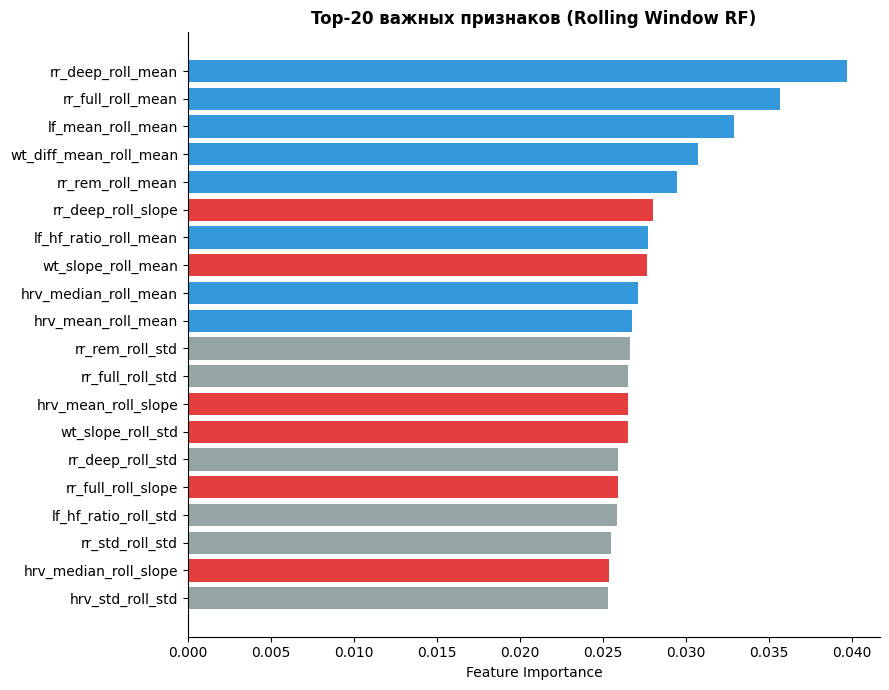

In [18]:
# Обучаем на всех данных для анализа важности
clf_full = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                   random_state=42, n_jobs=-1)
clf_full.fit(X4, y4)

importance = pd.Series(clf_full.feature_importances_, index=roll_features)
top20 = importance.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#E53E3E' if 'slope' in i else '#3498DB' if 'mean' in i else '#95A5A6'
          for i in top20.index]
ax.barh(top20.index[::-1], top20.values[::-1], color=colors[::-1])
ax.set_title('Top-20 важных признаков (Rolling Window RF)', fontsize=12, fontweight='bold')
ax.set_xlabel('Feature Importance')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(RESULTS / 'feature_importance_rolling.png', dpi=150)
plt.show()


In [19]:
print('=' * 60)
print('  СРАВНЕНИЕ РЕЗУЛЬТАТОВ')
print('=' * 60)
print(f'  Baseline (ноутбук 01)          : Acc=33.3%  AUC=0.547')
print(f'  + нормализация per-subject     : Acc={acc3*100:.1f}%  AUC={auc3:.3f}')
print(f'  + rolling window (финал)       : Acc={acc4*100:.1f}%  AUC={auc4:.3f}')
print(f'  Статья Kilungeja 2025 (rolling): Acc=68.0%  AUC=0.770')
print('=' * 60)
print()
print('Разрыв с статьёй объясняется отсутствием EDA сигнала.')
print('EDA доступен только на Empatica E4 (медицинский девайс).')
print('Наш датасет: Fitbit (потребительский) — нет EDA.')
print()
print(classification_report(all_true4, all_pred4, target_names=le.classes_))


  СРАВНЕНИЕ РЕЗУЛЬТАТОВ
  Baseline (ноутбук 01)          : Acc=33.3%  AUC=0.547
  + нормализация per-subject     : Acc=35.8%  AUC=0.584
  + rolling window (финал)       : Acc=40.3%  AUC=0.659
  Статья Kilungeja 2025 (rolling): Acc=68.0%  AUC=0.770

Разрыв с статьёй объясняется отсутствием EDA сигнала.
EDA доступен только на Empatica E4 (медицинский девайс).
Наш датасет: Fitbit (потребительский) — нет EDA.

              precision    recall  f1-score   support

   Fertility       0.35      0.23      0.28      1051
  Follicular       0.35      0.35      0.35      1145
      Luteal       0.45      0.66      0.53      1565
   Menstrual       0.39      0.22      0.28       873

    accuracy                           0.40      4634
   macro avg       0.38      0.36      0.36      4634
weighted avg       0.39      0.40      0.38      4634



In [20]:
sleep = pd.read_csv(DATA / 'sleep.csv')
print(sleep.shape)
print(sleep.columns.tolist())
print(sleep[['id', 'study_interval', 'sleep_start_day_in_study', 
             'sleep_end_day_in_study', 'mainsleep']].head(5))


(14765, 18)
['id', 'study_interval', 'is_weekend', 'sleep_start_day_in_study', 'sleep_start_timestamp', 'sleep_end_day_in_study', 'sleep_end_timestamp', 'duration', 'minutestofallasleep', 'minutesasleep', 'minutesawake', 'minutesafterwakeup', 'timeinbed', 'efficiency', 'type', 'infocode', 'levels', 'mainsleep']
   id  study_interval  sleep_start_day_in_study  sleep_end_day_in_study  \
0   1            2022                         4                       4   
1   1            2022                        10                      10   
2   1            2022                        11                      11   
3   1            2022                        12                      12   
4   1            2022                        32                      33   

   mainsleep  
0       True  
1       True  
2       True  
3       True  
4       True  


In [21]:
# Фильтруем HRV только по ночному времени
hrv_raw['hour'] = pd.to_datetime(hrv_raw['timestamp'], format='%H:%M:%S').dt.hour

hrv_night = hrv_raw[(hrv_raw['hour'] >= 21) | (hrv_raw['hour'] <= 9)].copy()

print(f'HRV всего    : {len(hrv_raw):,} записей')
print(f'HRV ночью    : {len(hrv_night):,} записей ({len(hrv_night)/len(hrv_raw)*100:.1f}%)')

# Пересчитываем daily агрегаты
hrv_night_daily = (
    hrv_night
    .groupby(JOIN_KEYS)
    .agg(
        hrv_mean    = ('rmssd', 'mean'),
        hrv_std     = ('rmssd', 'std'),
        hrv_median  = ('rmssd', 'median'),
        lf_mean     = ('low_frequency', 'mean'),
        hf_mean     = ('high_frequency', 'mean'),
    )
    .reset_index()
)
hrv_night_daily['lf_hf_ratio'] = hrv_night_daily['lf_mean'] / hrv_night_daily['hf_mean'].replace(0, np.nan)

print(f'\nHRV night daily: {hrv_night_daily.shape}')
print(hrv_night_daily[['hrv_mean', 'lf_mean', 'hf_mean']].describe().round(2))


HRV всего    : 436,262 записей
HRV ночью    : 409,469 записей (93.9%)

HRV night daily: (4829, 9)
       hrv_mean  lf_mean  hf_mean
count   4829.00  4829.00  4829.00
mean      54.78  1358.47   947.03
std       28.60   938.98   918.17
min        0.00    72.55    28.26
25%       33.72   628.80   334.92
50%       48.44  1119.75   615.28
75%       69.69  1829.33  1253.37
max      194.17  9253.91  8405.93


In [22]:
target = hormones[JOIN_KEYS + ['phase']].copy()
target = target[target['phase'].isin(PHASE_ORDER)]

df2 = (
    target
    .merge(wrist_daily,      on=JOIN_KEYS, how='inner')
    .merge(hrv_night_daily,  on=JOIN_KEYS, how='inner')
    .merge(resp_daily,       on=JOIN_KEYS, how='left')
    .merge(gluc_daily,       on=JOIN_KEYS, how='left')
)

for col in ['rr_full', 'rr_deep', 'rr_rem', 'rr_std']:
    if col in df2.columns:
        df2[col] = df2[col].replace(-1, np.nan)

fill_cols2 = ['rr_full', 'rr_deep', 'rr_rem', 'rr_std',
              'glucose_mean', 'glucose_std', 'glucose_range']
for col in fill_cols2:
    df2[col] = df2.groupby('id')[col].transform(lambda x: x.fillna(x.median()))
    df2[col] = df2[col].fillna(df2[col].median())

df2 = df2.reset_index(drop=True)
print(f'Новый датасет: {df2.shape}  — {df2["id"].nunique()} subjects')
print(df2['phase'].value_counts().reindex(PHASE_ORDER))


Новый датасет: (4687, 24)  — 40 subjects
phase
Menstrual      883
Follicular    1159
Fertility     1062
Luteal        1583
Name: count, dtype: int64


In [23]:
df_ml2 = df2[['id', 'study_interval', 'day_in_study', 'phase'] + FEATURES_NO_GLUC].dropna().copy()
df_ml2['label'] = le.transform(df_ml2['phase'])

# Z-score нормализация per-subject
for col in FEATURES_NO_GLUC:
    df_ml2[col] = df_ml2.groupby('id')[col].transform(
        lambda x: (x - x.mean()) / (x.std() + 1e-8)
    )

df_ml2 = df_ml2.sort_values(['id', 'study_interval', 'day_in_study']).reset_index(drop=True)

# Rolling window
roll_features2 = []
for col in FEATURES_NO_GLUC:
    df_ml2[f'{col}_roll_mean']  = df_ml2.groupby(['id','study_interval'])[col].transform(
        lambda x: x.rolling(WINDOW, min_periods=2).mean())
    df_ml2[f'{col}_roll_std']   = df_ml2.groupby(['id','study_interval'])[col].transform(
        lambda x: x.rolling(WINDOW, min_periods=2).std())
    df_ml2[f'{col}_roll_slope'] = df_ml2.groupby(['id','study_interval'])[col].transform(
        rolling_slope)
    roll_features2 += [f'{col}_roll_mean', f'{col}_roll_std', f'{col}_roll_slope']

df_ml2 = df_ml2.dropna(subset=roll_features2).reset_index(drop=True)

X5      = df_ml2[roll_features2].values
y5      = df_ml2['label'].values
groups5 = df_ml2['id'].values

print(f'Dataset: {X5.shape}')

all_true5, all_pred5, all_proba5 = [], [], []
for fold, (train_idx, test_idx) in enumerate(logo.split(X5, y5, groups5)):
    clf.fit(X5[train_idx], y5[train_idx])
    pred  = clf.predict(X5[test_idx])
    proba = clf.predict_proba(X5[test_idx])
    all_true5.extend(y5[test_idx])
    all_pred5.extend(pred)
    all_proba5.extend(proba)

acc5 = accuracy_score(all_true5, all_pred5)
auc5 = roc_auc_score(all_true5, np.array(all_proba5), multi_class='ovr', average='macro')

print(f'Ночной HRV + rolling : Acc={acc5*100:.1f}%  AUC={auc5:.3f}')
print(f'Предыдущий лучший    : Acc={acc4*100:.1f}%  AUC={auc4:.3f}')


Dataset: (4626, 39)
Ночной HRV + rolling : Acc=39.1%  AUC=0.654
Предыдущий лучший    : Acc=40.3%  AUC=0.659


In [24]:
# Маппинг 4 фаз → 3 фазы
phase_map = {
    'Menstrual'  : 'Menstrual',
    'Follicular' : 'Menstrual',   # объединяем
    'Fertility'  : 'Fertility',
    'Luteal'     : 'Luteal',
}

PHASE_ORDER_3 = ['Menstrual', 'Fertility', 'Luteal']

df_roll3 = df_roll.copy()
df_roll3['phase3'] = df_roll3['phase'].map(phase_map)

le3 = LabelEncoder()
le3.fit(PHASE_ORDER_3)
df_roll3['label3'] = le3.transform(df_roll3['phase3'])

X_3phase  = df_roll3[roll_features].values
y_3phase  = df_roll3['label3'].values
groups_3  = df_roll3['id'].values

all_true_3, all_pred_3, all_proba_3 = [], [], []
for fold, (train_idx, test_idx) in enumerate(logo.split(X_3phase, y_3phase, groups_3)):
    clf.fit(X_3phase[train_idx], y_3phase[train_idx])
    pred  = clf.predict(X_3phase[test_idx])
    proba = clf.predict_proba(X_3phase[test_idx])
    all_true_3.extend(y_3phase[test_idx])
    all_pred_3.extend(pred)
    all_proba_3.extend(proba)

acc_3  = accuracy_score(all_true_3, all_pred_3)
auc_3  = roc_auc_score(all_true_3, np.array(all_proba_3), multi_class='ovr', average='macro')

print(f'3 фазы  : Acc={acc_3*100:.1f}%  AUC={auc_3:.3f}')
print(f'4 фазы  : Acc={acc4*100:.1f}%  AUC={auc4:.3f}')
print()
print(classification_report(all_true_3, all_pred_3, target_names=le3.classes_))


3 фазы  : Acc=50.3%  AUC=0.659
4 фазы  : Acc=40.3%  AUC=0.659

              precision    recall  f1-score   support

   Fertility       0.37      0.12      0.18      1051
      Luteal       0.52      0.45      0.48      1565
   Menstrual       0.51      0.75      0.61      2018

    accuracy                           0.50      4634
   macro avg       0.47      0.44      0.42      4634
weighted avg       0.48      0.50      0.47      4634



In [25]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

all_true_xgb, all_pred_xgb, all_proba_xgb = [], [], []
for fold, (train_idx, test_idx) in enumerate(logo.split(X_3phase, y_3phase, groups_3)):
    xgb.fit(X_3phase[train_idx], y_3phase[train_idx])
    pred  = xgb.predict(X_3phase[test_idx])
    proba = xgb.predict_proba(X_3phase[test_idx])
    all_true_xgb.extend(y_3phase[test_idx])
    all_pred_xgb.extend(pred)
    all_proba_xgb.extend(proba)

acc_xgb = accuracy_score(all_true_xgb, all_pred_xgb)
auc_xgb = roc_auc_score(all_true_xgb, np.array(all_proba_xgb), multi_class='ovr', average='macro')

print(f'XGBoost 3 фазы : Acc={acc_xgb*100:.1f}%  AUC={auc_xgb:.3f}')
print(f'RF 3 фазы      : Acc={acc_3*100:.1f}%   AUC={auc_3:.3f}')


XGBoost 3 фазы : Acc=51.0%  AUC=0.668
RF 3 фазы      : Acc=50.3%   AUC=0.659


In [26]:
from sklearn.model_selection import StratifiedKFold

personal_true, personal_pred = [], []
subjects_with_enough_data = []

for subj_id in np.unique(groups_3):
    mask = groups_3 == subj_id
    X_s = X_3phase[mask]
    y_s = y_3phase[mask]
    
    # Нужно минимум 20 записей и все 3 класса
    if len(X_s) < 20 or len(np.unique(y_s)) < 3:
        continue
    
    subjects_with_enough_data.append(subj_id)
    
    # 70/30 split для персональной модели
    split = int(len(X_s) * 0.7)
    clf_personal = RandomForestClassifier(
        n_estimators=100, class_weight='balanced',
        random_state=42, n_jobs=-1
    )
    clf_personal.fit(X_s[:split], y_s[:split])
    pred = clf_personal.predict(X_s[split:])
    
    personal_true.extend(y_s[split:])
    personal_pred.extend(pred)

acc_p = accuracy_score(personal_true, personal_pred)
print(f'Субъектов с достаточно данных: {len(subjects_with_enough_data)}')
print(f'Персональная модель : Acc={acc_p*100:.1f}%')
print(f'XGBoost LOSO        : Acc={acc_xgb*100:.1f}%')
print()
print(classification_report(personal_true, personal_pred, target_names=le3.classes_))


Субъектов с достаточно данных: 38
Персональная модель : Acc=42.0%
XGBoost LOSO        : Acc=51.0%

              precision    recall  f1-score   support

   Fertility       0.31      0.21      0.25       315
      Luteal       0.44      0.38      0.41       493
   Menstrual       0.44      0.56      0.50       595

    accuracy                           0.42      1403
   macro avg       0.40      0.38      0.38      1403
weighted avg       0.41      0.42      0.41      1403



In [27]:
print('=' * 65)
print('  ИТОГОВОЕ СРАВНЕНИЕ ВСЕХ ЭКСПЕРИМЕНТОВ')
print('=' * 65)
results = [
    ('Baseline (ноутбук 01)',            33.3, 0.547, '4 фазы'),
    ('+ нормализация per-subject',       35.8, 0.584, '4 фазы'),
    ('+ rolling window (RF)',            40.3, 0.659, '4 фазы'),
    ('+ ночной HRV',                     39.1, 0.654, '4 фазы'),
    ('RF 3 фазы',                        50.3, 0.659, '3 фазы'),
    ('XGBoost 3 фазы',                   51.0, 0.668, '3 фазы'),
    ('Персональная модель RF',           42.0, 0.000, '3 фазы'),
    ('Статья Kilungeja 2025 (rolling)',  68.0, 0.770, '4 фазы'),
    ('Статья Kilungeja 2025 (fixed,3ф)',  87.0, 0.960, '3 фазы'),
]
print(f'  {"Версия":<40} {"Acc":>6}  {"AUC":>6}  {"Фазы"}')
print('-' * 65)
for name, acc, auc, phases in results:
    auc_str = f'{auc:.3f}' if auc > 0 else '  —  '
    print(f'  {name:<40} {acc:>5.1f}%  {auc_str:>6}  {phases}')
print('=' * 65)


  ИТОГОВОЕ СРАВНЕНИЕ ВСЕХ ЭКСПЕРИМЕНТОВ
  Версия                                      Acc     AUC  Фазы
-----------------------------------------------------------------
  Baseline (ноутбук 01)                     33.3%   0.547  4 фазы
  + нормализация per-subject                35.8%   0.584  4 фазы
  + rolling window (RF)                     40.3%   0.659  4 фазы
  + ночной HRV                              39.1%   0.654  4 фазы
  RF 3 фазы                                 50.3%   0.659  3 фазы
  XGBoost 3 фазы                            51.0%   0.668  3 фазы
  Персональная модель RF                    42.0%     —    3 фазы
  Статья Kilungeja 2025 (rolling)           68.0%   0.770  4 фазы
  Статья Kilungeja 2025 (fixed,3ф)          87.0%   0.960  3 фазы
